# 🤖 Notebook 2 — Modélisation : Succès Commercial & Rentabilité
## Projet : Prédiction du succès commercial des films Bollywood

---

### 🗂️ Position dans l'architecture

```
bollywood_merged_clean.csv  ← INPUT (sorti du Notebook 1)
         │
         ▼
 ┌───────────────────────────────────────────────────────┐
 │  CE NOTEBOOK                                          │
 │                                                       │
 │  Préparation ML  ──►  GaussianNB  ──►  Évaluation    │
 │       │           └►  RandomForest ──►  Évaluation   │
 │       │                                               │
 │       ▼                                               │
 │  Cible 1 : Success_Class  (Flop / Average / Hit)      │
 │  Cible 2 : Profitability_Class (Low/Medium/High ROI)  │
 └───────────────────────────────────────────────────────┘
         │
         ▼
 models/  (gnb_success.pkl, rf_success.pkl, gnb_profit.pkl, rf_profit.pkl, ...)
```

### 📋 Variables cibles

| Variable | Source | Classes | Seuils |
|----------|--------|---------|--------|
| `Success_Class` | `Revenue(INR)` | Flop / Average / Hit | Tertiles |
| `Profitability_Class` | `ROI` | Low ROI / Medium ROI / High ROI | Tertiles |

### 📋 Variables explicatives

| Feature | Type | Justification |
|---------|------|---------------|
| `Budget(INR)` | Numérique | Investissement = signal fort |
| `Number of Screens` | Numérique | Distribution = levier |
| `Rating(10)` | Numérique | Qualité perçue |
| `Votes` | Numérique | Popularité |
| `Genre` | Catégorielle encodée | Contexte métier |

---
## 1. 📦 Imports & Configuration

---
## 2. 📂 Chargement du dataset nettoyé

In [40]:
df = pd.read_csv(DATA_PATH)
print(f'✅ Dataset chargé : {df.shape[0]} films × {df.shape[1]} colonnes')
display(df.head(3))
print()
display(df.describe())

✅ Dataset chargé : 1349 films × 13 colonnes


,Movie Name,Release Period,Genre,New Music Director,Number of Screens,Revenue(INR),Budget(INR),Timing(min),Rating(10),Votes,Language,Profit(INR),ROI
0,apna sapna money money,normal,comedy,no,450,95000000,207325000,134.0,5.3,1892.0,hindi,-112325000,0.458218
1,sunday,holiday,comedy,no,900,220000000,319615000,135.0,5.3,2592.0,hindi,-99615000,0.688328
2,red alert the war within,normal,drama,no,400,100000000,19300000,120.0,6.4,337.0,hindi,80700000,5.181347


,Number of Screens,Revenue(INR),Budget(INR),Timing(min),Rating(10),Votes,Profit(INR),ROI
count,1349.000000,1.349000e+03,1.349000e+03,1349.000000,1349.000000,1349.000000,1.349000e+03,1349.000000
mean,759.876946,2.077616e+08,3.284373e+08,130.202372,5.658710,5320.656042,-1.206757e+08,11.066240
std,821.446876,2.538944e+08,6.192280e+08,22.373743,1.442408,15257.362941,4.315487e+08,74.710388
min,2.000000,1.000000e+06,1.400000e+04,16.000000,1.700000,5.000000,-5.704750e+09,0.119237
25%,135.000000,4.000000e+07,6.500000e+06,117.000000,4.600000,148.000000,-1.196500e+08,0.649123
50%,450.000000,1.100000e+08,6.784000e+07,130.000000,5.700000,852.000000,1.447500e+07,1.625000
75%,1150.000000,2.900000e+08,4.083700e+08,144.000000,6.800000,4709.000000,4.867500e+07,6.557377
max,4600.000000,2.100000e+09,7.024750e+09,240.000000,9.100000,351187.000000,7.486350e+08,1714.285714


---
## 3. 🎯 Construction des variables cibles

Les seuils sont définis **par tertiles** (33e et 67e percentiles) pour garantir des classes équilibrées,
ce qui est important pour Naive Bayes.

```
Success_Class :
  Revenue < Q33  →  Flop
  Q33 ≤ Revenue < Q67  →  Average
  Revenue ≥ Q67  →  Hit

Profitability_Class :
  ROI < Q33  →  Low ROI
  Q33 ≤ ROI < Q67  →  Medium ROI
  ROI ≥ Q67  →  High ROI
```

In [41]:
# ── Cible 1 : Success_Class basée sur Revenue ─────────────────
rev_q33 = df['Revenue(INR)'].quantile(0.33)
rev_q67 = df['Revenue(INR)'].quantile(0.67)

def label_success(rev):
    if rev < rev_q33:  return 'Flop'
    elif rev < rev_q67: return 'Average'
    else:               return 'Hit'

df['Success_Class'] = df['Revenue(INR)'].apply(label_success)

# ── Cible 2 : Profitability_Class basée sur ROI ───────────────
roi_q33 = df['ROI'].quantile(0.33)
roi_q67 = df['ROI'].quantile(0.67)

def label_profit(roi):
    if roi < roi_q33:  return 'Low ROI'
    elif roi < roi_q67: return 'Medium ROI'
    else:               return 'High ROI'

df['Profitability_Class'] = df['ROI'].apply(label_profit)

print('── Seuils Success_Class ──')
print(f'   Flop    : Revenue < {rev_q33/1e6:.1f} M INR')
print(f'   Average : {rev_q33/1e6:.1f} ≤ Revenue < {rev_q67/1e6:.1f} M INR')
print(f'   Hit     : Revenue ≥ {rev_q67/1e6:.1f} M INR')
print()
print('── Seuils Profitability_Class ──')
print(f'   Low ROI    : ROI < {roi_q33:.2f}')
print(f'   Medium ROI : {roi_q33:.2f} ≤ ROI < {roi_q67:.2f}')
print(f'   High ROI   : ROI ≥ {roi_q67:.2f}')
print()
print('── Distribution des classes ──')
print(df['Success_Class'].value_counts())
print()
print(df['Profitability_Class'].value_counts())

# Sauvegarder les seuils pour l'application
seuils = {
    'rev_q33': rev_q33, 'rev_q67': rev_q67,
    'roi_q33': roi_q33, 'roi_q67': roi_q67
}
with open(MODELS_DIR / 'seuils.json', 'w') as f:
    json.dump(seuils, f, indent=2)
print('\n✅ Seuils sauvegardés → models/seuils.json')

── Seuils Success_Class ──
   Flop    : Revenue < 60.0 M INR
   Average : 60.0 ≤ Revenue < 220.0 M INR
   Hit     : Revenue ≥ 220.0 M INR

── Seuils Profitability_Class ──
   Low ROI    : ROI < 0.85
   Medium ROI : 0.85 ≤ ROI < 4.27
   High ROI   : ROI ≥ 4.27

── Distribution des classes ──
Success_Class
Average    454
Hit        453
Flop       442
Name: count, dtype: int64

Profitability_Class
Medium ROI    460
High ROI      445
Low ROI       444
Name: count, dtype: int64

✅ Seuils sauvegardés → models/seuils.json


---
## 4. 📊 Visualisation des classes

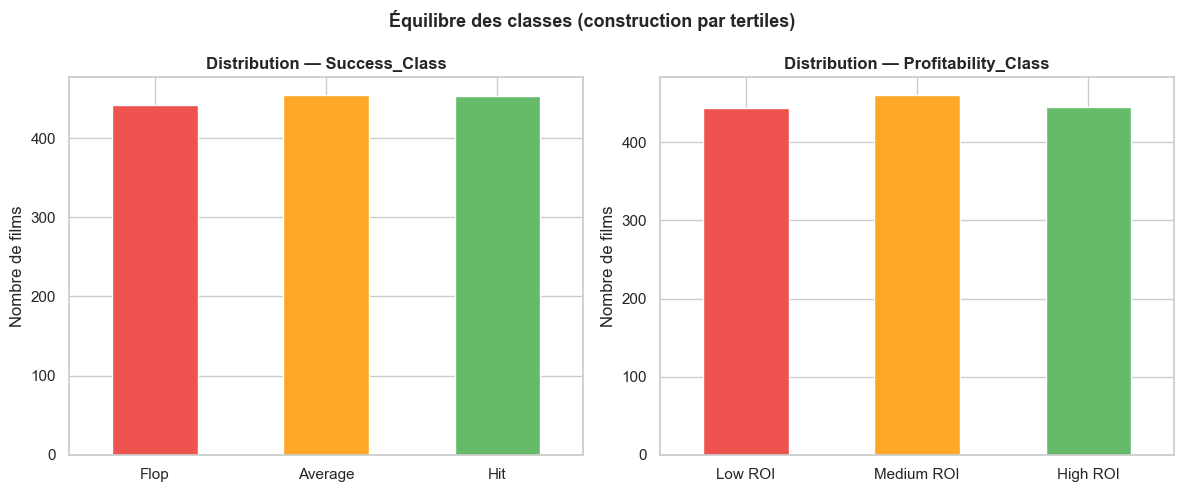

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Success_Class
order_s = ['Flop', 'Average', 'Hit']
colors_s = ['#EF5350', '#FFA726', '#66BB6A']
df['Success_Class'].value_counts().reindex(order_s).plot(
    kind='bar', ax=axes[0], color=colors_s, edgecolor='white'
)
axes[0].set_title('Distribution — Success_Class', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nombre de films')
axes[0].tick_params(axis='x', rotation=0)

# Profitability_Class
order_p = ['Low ROI', 'Medium ROI', 'High ROI']
colors_p = ['#EF5350', '#FFA726', '#66BB6A']
df['Profitability_Class'].value_counts().reindex(order_p).plot(
    kind='bar', ax=axes[1], color=colors_p, edgecolor='white'
)
axes[1].set_title('Distribution — Profitability_Class', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Nombre de films')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Équilibre des classes (construction par tertiles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. 🔧 Préparation des features pour le ML

### Schéma du pipeline de préparation

```
df brut
  │
  ├──► Features numériques : Budget, Screens, Rating, Votes
  │         (déjà propres après Notebook 1)
  │
  └──► Genre (catégorielle)
            │
            └──► LabelEncoder ──► Genre_Encoded (int)
                     │
                     └── sauvegardé : le_genre.pkl
```

In [43]:
FEATURES = ['Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes', 'Genre_Encoded']

# Encodage du genre
le_genre = LabelEncoder()
df['Genre_Encoded'] = le_genre.fit_transform(df['Genre'])

# Sauvegarde de l'encodeur
joblib.dump(le_genre, MODELS_DIR / 'le_genre.pkl')
print(f'✅ LabelEncoder sauvegardé → models/le_genre.pkl')
print(f'   Genres encodés : {dict(zip(le_genre.classes_, le_genre.transform(le_genre.classes_)))}')

# Features et cibles
X = df[FEATURES].copy()

y_success = df['Success_Class']
y_profit  = df['Profitability_Class']

print(f'\n✅ Matrice X : {X.shape}')
display(X.head(3))

# Sauvegarde des noms de features
with open(MODELS_DIR / 'features.json', 'w') as f:
    json.dump(FEATURES, f)
print('\n✅ Features sauvegardées → models/features.json')

✅ LabelEncoder sauvegardé → models/le_genre.pkl
   Genres encodés : {'action': np.int64(0), 'comedy': np.int64(1), 'drama': np.int64(2), 'love_story': np.int64(3), 'rom__com': np.int64(4), 'thriller': np.int64(5)}

✅ Matrice X : (1349, 5)


,Budget(INR),Number of Screens,Rating(10),Votes,Genre_Encoded
0,207325000,450,5.3,1892.0,1
1,319615000,900,5.3,2592.0,1
2,19300000,400,6.4,337.0,2



✅ Features sauvegardées → models/features.json


---
## 6. ✂️ Split Train / Test (80/20)

In [44]:
X_train, X_test, ys_train, ys_test = train_test_split(
    X, y_success, test_size=0.2, random_state=SEED, stratify=y_success
)
_, _, yp_train, yp_test = train_test_split(
    X, y_profit, test_size=0.2, random_state=SEED, stratify=y_profit
)

print(f'✅ Train : {X_train.shape[0]} films | Test : {X_test.shape[0]} films')
print(f'   Répartition train Success_Class :')
print(ys_train.value_counts())

✅ Train : 1079 films | Test : 270 films
   Répartition train Success_Class :
Success_Class
Average    363
Hit        362
Flop       354
Name: count, dtype: int64


---
## 7. 🏋️ Entraînement des modèles

### Pourquoi ces deux modèles ?

| Modèle | Principe | Avantage pour ce projet |
|--------|----------|-------------------------|
| **Gaussian Naive Bayes** | Hypothèse d'indépendance conditionnelle des features, distribution gaussienne | Rapide, interprétable, baseline solide |
| **Random Forest** | Ensemble d'arbres de décision, vote majoritaire | Capture les interactions non-linéaires, robuste aux outliers |

### Schéma Random Forest

```
      X_train
         │
    ┌────┴────────────────────┐
  Arbre 1   Arbre 2  ...  Arbre N
    │          │              │
  pred_1    pred_2  ...    pred_N
    └──────────┬──────────────┘
           Vote majoritaire
               │
          Classe finale
```

In [45]:
# ── Gaussian Naive Bayes ──────────────────────────────────────
gnb_success = GaussianNB()
gnb_success.fit(X_train, ys_train)

gnb_profit = GaussianNB()
gnb_profit.fit(X_train, yp_train)

# ── Random Forest ─────────────────────────────────────────────
rf_success = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf_success.fit(X_train, ys_train)

rf_profit = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf_profit.fit(X_train, yp_train)

# ── Sauvegarde des modèles ─────────────────────────────────────
joblib.dump(gnb_success, MODELS_DIR / 'gnb_success.pkl')
joblib.dump(gnb_profit,  MODELS_DIR / 'gnb_profit.pkl')
joblib.dump(rf_success,  MODELS_DIR / 'rf_success.pkl')
joblib.dump(rf_profit,   MODELS_DIR / 'rf_profit.pkl')

print('✅ 4 modèles entraînés et sauvegardés :')
print('   models/gnb_success.pkl')
print('   models/gnb_profit.pkl')
print('   models/rf_success.pkl')
print('   models/rf_profit.pkl')

✅ 4 modèles entraînés et sauvegardés :
   models/gnb_success.pkl
   models/gnb_profit.pkl
   models/rf_success.pkl
   models/rf_profit.pkl


---
## 8. 📈 Évaluation & Comparaison des modèles

> **Métriques utilisées** : Accuracy, Precision (macro), Recall (macro), F1-score (macro)  
> L'utilisation de la moyenne **macro** est adaptée aux classes équilibrées.

In [46]:
def evaluate_model(name, model, X_t, y_t):
    y_pred = model.predict(X_t)
    acc = accuracy_score(y_t, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_t, y_pred, average='macro', zero_division=0)
    return {'Modèle': name, 'Accuracy': round(acc,4),
            'Precision_macro': round(prec,4),
            'Recall_macro': round(rec,4),
            'F1_macro': round(f1,4)}

results_success = pd.DataFrame([
    evaluate_model('GaussianNB — Success',    gnb_success, X_test, ys_test),
    evaluate_model('Random Forest — Success', rf_success,  X_test, ys_test),
])

results_profit = pd.DataFrame([
    evaluate_model('GaussianNB — Profitability',    gnb_profit, X_test, yp_test),
    evaluate_model('Random Forest — Profitability', rf_profit,  X_test, yp_test),
])

print('── Résultats : Prédiction du Succès ──')
display(results_success)
print('\n── Résultats : Prédiction de la Rentabilité ──')
display(results_profit)

── Résultats : Prédiction du Succès ──


,Modèle,Accuracy,Precision_macro,Recall_macro,F1_macro
0,GaussianNB — Success,0.6407,0.6577,0.6443,0.6279
1,Random Forest — Success,0.8259,0.8273,0.8266,0.8269



── Résultats : Prédiction de la Rentabilité ──


,Modèle,Accuracy,Precision_macro,Recall_macro,F1_macro
0,GaussianNB — Profitability,0.3037,0.2351,0.3070,0.1947
1,Random Forest — Profitability,0.3148,0.3167,0.3147,0.3150


---
## 9. 🧮 Matrices de confusion

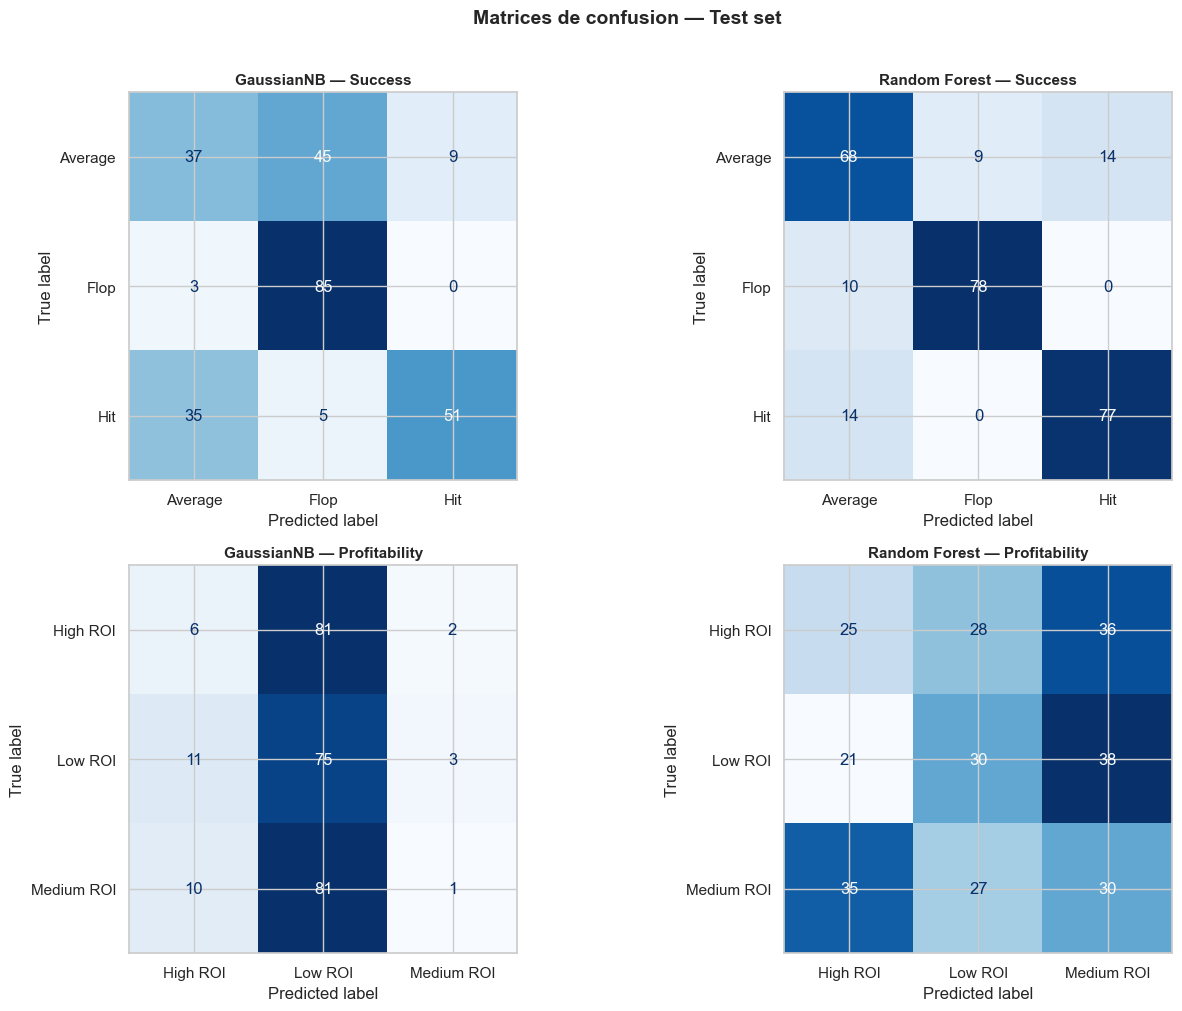

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    (gnb_success, X_test, ys_test, 'GaussianNB — Success',        axes[0][0]),
    (rf_success,  X_test, ys_test, 'Random Forest — Success',     axes[0][1]),
    (gnb_profit,  X_test, yp_test, 'GaussianNB — Profitability',  axes[1][0]),
    (rf_profit,   X_test, yp_test, 'Random Forest — Profitability', axes[1][1]),
]

for model, X_t, y_t, title, ax in configs:
    y_pred = model.predict(X_t)
    cm = confusion_matrix(y_t, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold', fontsize=11)

plt.suptitle('Matrices de confusion — Test set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. 🔁 Validation croisée (5-Fold)

> La validation croisée permet d'évaluer la **généralisation** du modèle sur l'ensemble du dataset,  
> sans biais lié au split train/test particulier choisi.

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, model, y in [
    ('GaussianNB — Success',       gnb_success, y_success),
    ('RandomForest — Success',     rf_success,  y_success),
    ('GaussianNB — Profitability', gnb_profit,  y_profit),
    ('RandomForest — Profitability', rf_profit, y_profit),
]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = {'F1 moyen': round(scores.mean(), 4),
                         'Écart-type': round(scores.std(), 4)}

cv_df = pd.DataFrame(cv_results).T
print('── Validation croisée 5-Fold (F1 macro) ──')
display(cv_df)

── Validation croisée 5-Fold (F1 macro) ──


,F1 moyen,Écart-type
GaussianNB — Success,0.6580,0.0152
RandomForest — Success,0.8669,0.0136
GaussianNB — Profitability,0.7101,0.0277
RandomForest — Profitability,0.8699,0.0191


---
## 11. 🔍 Importance des features (Random Forest)

> Avantage du Random Forest : il fournit une mesure d'importance par feature,  
> utile pour **expliquer** les prédictions en soutenance.

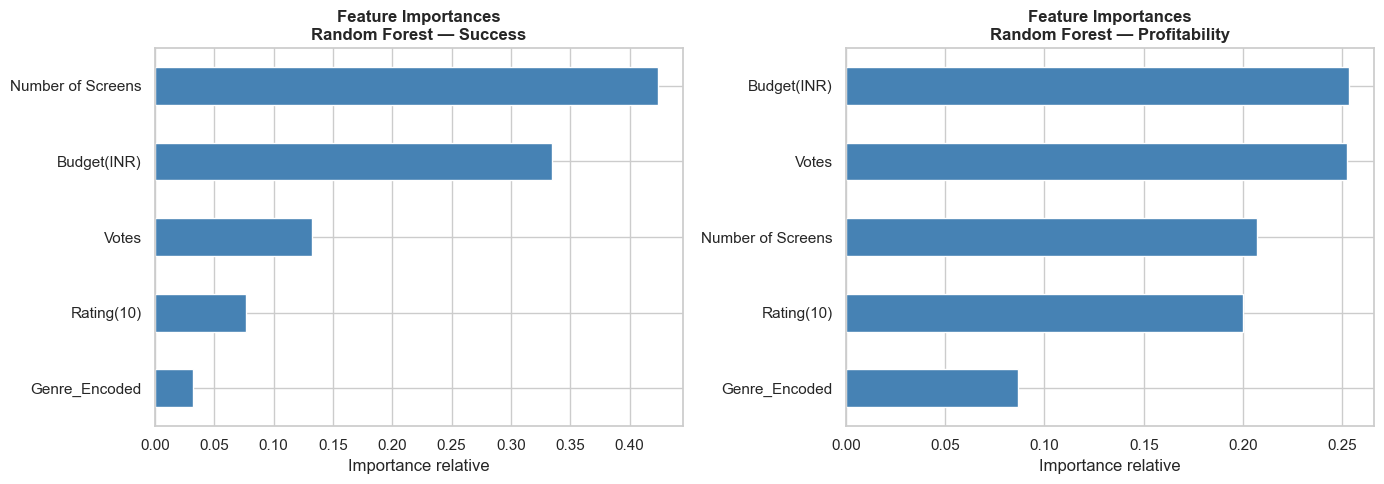

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in [
    (axes[0], rf_success, 'Random Forest — Success'),
    (axes[1], rf_profit,  'Random Forest — Profitability'),
]:
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature Importances\n{title}', fontweight='bold')
    ax.set_xlabel('Importance relative')

plt.tight_layout()
plt.show()

---
## 12. 💾 Export des métriques pour l'application

In [50]:
all_metrics = pd.concat([results_success, results_profit], ignore_index=True)
metrics_dict = all_metrics.set_index('Modèle').to_dict(orient='index')

with open(MODELS_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print('✅ Métriques exportées → models/metrics.json')
print()

# Vérification : rechargement d'un modèle et prédiction test
print('── Test de rechargement des modèles ──')
rf_s_loaded = joblib.load(MODELS_DIR / 'rf_success.pkl')
le_loaded   = joblib.load(MODELS_DIR / 'le_genre.pkl')

exemple = pd.DataFrame([{
    'Budget(INR)': 200_000_000,
    'Number of Screens': 1000,
    'Rating(10)': 6.5,
    'Votes': 5000,
    'Genre_Encoded': int(le_loaded.transform(['comedy'])[0])
}])

pred = rf_s_loaded.predict(exemple)[0]
proba = rf_s_loaded.predict_proba(exemple)[0]
print(f'   Film test → Classe prédite : {pred}')
print(f'   Probabilités : {dict(zip(rf_s_loaded.classes_, proba.round(3)))}')


✅ Métriques exportées → models/metrics.json

── Test de rechargement des modèles ──
   Film test → Classe prédite : Average
   Probabilités : {'Average': np.float64(0.602), 'Flop': np.float64(0.002), 'Hit': np.float64(0.396)}
